## Audio como Dato
## G1: Joaquín Batista, Milagros Cancela, Valentín Rodríguez, Alexia Aurrecoechea, Nahuel López
**Ingeniería de Datos — Universidad Católica del Uruguay**
---
Objetivo: Diseñar e implementar un pipeline de preprocesamiento de audio que incorpore carga, inspección visual, limpieza básica, extracción de MFCC y exportación de features listos para ML.

## Setup y Carga de Datos
#### Instalación rápida

In [4]:
!pip3 install -q librosa soundfile numpy matplotlib pandas scipy --break-system-packages

import librosa
import librosa.display
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pathlib, warnings, platform, os

warnings.filterwarnings("ignore")

print("✅ Librerías listas")
print(f"librosa: {librosa.__version__}")
print(f"soundfile: {sf.__libs__ if hasattr(sf, '__libs__') else 'OK'}")
print(f"Python: {platform.python_version()}")

✅ Librerías listas
librosa: 0.11.0
soundfile: OK
Python: 3.13.5


## 0) Dataset
Primero cargá tus credenciales (subirás kaggle.json desde el panel de Colab):

In [6]:
import os
import json
import shutil

print("=" * 70)
print("📁 CARGANDO CREDENCIALES DE KAGGLE (RUTA MANUAL)")
print("=" * 70)
print("\n⚠️  Asegúrate de haber descargado tu archivo 'kaggle.json' desde Kaggle.\n")
print("    Luego, especifica su ruta completa en la variable 'file_path' del código.\n")

file_path = "~/.kaggle/kaggle.json"

# Verificar que el archivo exista
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ No se encontró el archivo en la ruta especificada:\n{file_path}")

print(f"✅ Archivo encontrado: {file_path}\n")

# Crear el directorio ~/.kaggle si no existe
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Copiar el archivo kaggle.json al directorio correcto
kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
shutil.copy(file_path, kaggle_json_path)

# Establecer permisos adecuados (solo lectura/escritura para el usuario)
try:
    os.chmod(kaggle_json_path, 0o600)
except Exception:
    pass  # En Windows puede no aplicarse este permiso

print(f"✅ Credenciales guardadas en: {kaggle_json_path}")

# Verificar credenciales cargadas
with open(kaggle_json_path, "r") as f:
    creds = json.load(f)
    username = creds.get("username", "desconocido")

print(f"✅ Usuario Kaggle detectado: {username}")
print("\n" + "=" * 70)

# ---------------------------------------------------------------------
# Verificar instalación del paquete kaggle
try:
    import kaggle
    print(" Paquete 'kaggle' instalado correctamente.")
except ImportError:
    print(" Paquete 'kaggle' no encontrado. Instalando automáticamente...")
    os.system("pip install kaggle")
    import kaggle
    print("✅ Paquete 'kaggle' instalado y listo para usar.")

print("=" * 70)
print("🚀 Kaggle API configurada correctamente. Ya podés descargar datasets.")
print("=" * 70)

📁 CARGANDO CREDENCIALES DE KAGGLE (RUTA MANUAL)

⚠️  Asegúrate de haber descargado tu archivo 'kaggle.json' desde Kaggle.

    Luego, especifica su ruta completa en la variable 'file_path' del código.

✅ Archivo encontrado: ~/.kaggle/kaggle.json

✅ Credenciales guardadas en: ~/.kaggle/kaggle.json
✅ Usuario Kaggle detectado: [TU_USUARIO_KAGGLE]

 Paquete 'kaggle' instalado correctamente.
🚀 Kaggle API configurada correctamente. Ya podés descargar datasets.


Luego descargá el dataset con kagglehub:

In [9]:
print("\n=== DESCARGANDO chrisfilo/urbansound8kDESDE KAGGLE ===\n")

# Instalar kaggle si no está instalado
from kaggle.api.kaggle_api_extended import KaggleApi

# Autenticar con API
api = KaggleApi()
api.authenticate()
print("✅ Autenticación exitosa con Kaggle API\n")

# Dataset reference para UrbanSound8K
dataset_ref = "chrisfilo/urbansound8k"
download_path = "./data"

# Crear directorio si no existe
os.makedirs(download_path, exist_ok=True)

# Descargar archivos
print(f"📥 Descargando dataset: {dataset_ref}")
print(f"📂 Destino: {download_path}")

api.dataset_download_files(
    dataset_ref,
    path=download_path,
    unzip=True  # Descomprime automáticamente
)

print("✅ Descarga completada\n")

# Listar archivos descargados
print(f"📋 Archivos disponibles en {download_path}:")
for file in sorted(os.listdir(download_path)):
    file_path = os.path.join(download_path, file)
    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"   ✅ {file:40s} ({size_mb:7.2f} MB)")


=== DESCARGANDO chrisfilo/urbansound8kDESDE KAGGLE ===

✅ Autenticación exitosa con Kaggle API

📥 Descargando dataset: chrisfilo/urbansound8k
📂 Destino: ./data
Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
✅ Descarga completada

📋 Archivos disponibles en ./data:
   ✅ UrbanSound8K.csv                         (   0.47 MB)


Más info:
- Documentación de credenciales de Kaggle: https://www.kaggle.com/docs/api#getting-started-installation-&-authentication
- Documentación de kagglehub: https://github.com/Kaggle/kagglehub
- Si estás trabajando directamente en un notebook de Kaggle (sin copiar archivos), el dataset ya está montado en /kaggle/input/urbansound8k. Podés inspeccionarlo con:

In [11]:
from pathlib import Path

RAW_DIR = Path("./data")
audio_files = sorted([
    p for p in RAW_DIR.glob("**/*")
    if p.suffix.lower() in {".wav", ".mp3", ".flac", ".ogg"}
])

print("Audios encontrados:", len(audio_files))
audio_files[:5]

Audios encontrados: 8732


[PosixPath('./data PosixPath('./data PosixPath('./data PosixPath('./data PosixPath('./data

El resultado suele ser ~8732 archivos y los primeros WAV pertenecen al fold1. Si querés copiar estos archivos al directorio local data/raw/, iterá sobre audio_files y escribilos donde necesites.

## 1) Directorios de trabajo

In [12]:
OUTPUTS = {
    "waveforms": pathlib.Path("outputs/waveforms"),
    "specs": pathlib.Path("outputs/specs"),
    "features": pathlib.Path("outputs/features"),
    "metrics": pathlib.Path("outputs/metrics"),
}

for out in OUTPUTS.values():
    out.mkdir(parents=True, exist_ok=True)

print("Carpetas de salida creadas")

Carpetas de salida creadas


# Parte A — Representación e inspección inicial
## A.1 Carga y stats básicas

In [14]:
from pathlib import Path

def load_audio(path: Path, sr: int | None = None, mono: bool = False):
    """Carga un archivo de audio con librosa."""
    y, sr = librosa.load(path.as_posix(), sr=sr, mono=mono)
    return y, sr

root = Path(r"./data")
audio_files = sorted(root.rglob("fold*/**/*.wav"))
print("Audios encontrados:", len(audio_files))
assert audio_files, "❌ No se encontraron audios en el dataset."
audio_path = audio_files[0]
print("Ejemplo seleccionado:", audio_path)

y, sr = load_audio(audio_path, sr=None, mono=False)
print("Archivo:", audio_path.name)
print("Forma:", y.shape, "dtype:", y.dtype)
print("Sample rate original:", sr)

duration_sec = len(y) / sr if y.ndim == 1 else y.shape[-1] / sr
channels = 1 if y.ndim == 1 else y.shape[0]

if y.ndim > 1:
    y_mono = np.mean(y, axis=0)
else:
    y_mono = y

print("Duración (s):", round(duration_sec, 3))
print("Canales:", channels)
print("Amplitud min/max:", round(float(y_mono.min()), 4),
      round(float(y_mono.max()), 4))
print("Media:", round(float(y_mono.mean()), 4),
      "STD:", round(float(y_mono.std()), 4))

Audios encontrados: 8732
Ejemplo seleccionado: ./dataArchivo: 101415-3-0-2.wav
Forma: (192000,) dtype: float32
Sample rate original: 48000
Duración (s): 4.0
Canales: 1
Amplitud min/max: -0.8535 0.8065
Media: -0.0 STD: 0.1133


## A.2 Waveform en el tiempo

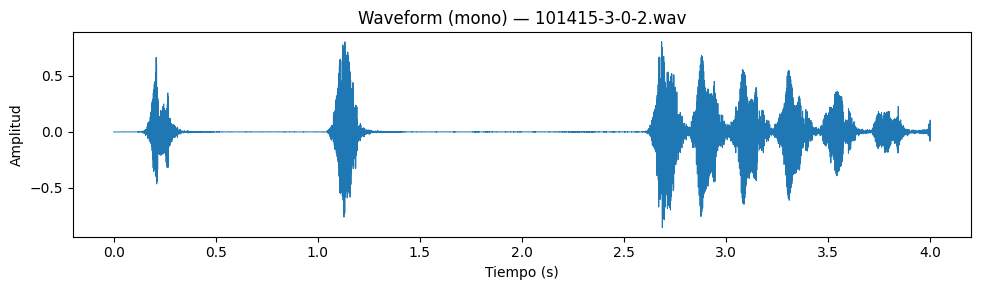

In [15]:
t = np.linspace(0, duration_sec, num=y_mono.shape[-1])
plt.figure(figsize=(10, 3))
plt.plot(t, y_mono, linewidth=0.7)
plt.title(f"Waveform (mono) — {audio_path.name}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

## 📝 Preguntas de reflexión — Parte A

- El audio dura aproximadamente 4.0 segundos y tiene sample rate 48.000 Hz.
- La amplitud oscila entre –0.8535 y 0.8065, lo que indica que el clip está normalizado porque los valores se mantienen dentro del rango típico [–1.0, +1.0] de señales de audio en punto flotante.
- El número de canales es 1; trabajar en mono es adecuado/no adecuado porque no existe información estéreo que se perdería y el análisis se simplifica.
- El tipo de dato (dtype) de y es float32 y los valores típicos están en el rango [–0.8535, 0.8065]; esto sugiere que la señal está normalizada porque sus valores están dentro del rango estándar de audio digital normalizado (–1, 1) y no supera esos límites.
- Si observáramos muchos valores cerca de -1.0 o +1.0, esto indicaría potencialmente clipping, lo cual es problemático porque distorsiona la señal, elimina información del sonido, introduce artefactos que afectan la calidad y puede perjudicar tareas de clasificación, ya que altera patrones espectrales.

# Parte B — Estandarización del audio
Objetivo: unificar sample rate, mono, duración y amplitud para alimentar el pipeline.

In [16]:
TARGET_SR = 16000          # Hz
TARGET_DURATION = 3.0      # segundos
TARGET_AMPLITUDE = 0.99
TOP_DB = 30.0              # recorte de silencios

def preprocess_audio(path: Path,
                     target_sr: int = TARGET_SR,
                     target_duration: float = TARGET_DURATION,
                     top_db: float = TOP_DB) -> tuple[np.ndarray, int]:
    y, sr = load_audio(path, sr=None, mono=False)

    if y.ndim > 1:
        y = np.mean(y, axis=0)

    y_trim, _ = librosa.effects.trim(y, top_db=top_db)

    if sr != target_sr:
        y_rs = librosa.resample(y_trim, orig_sr=sr, target_sr=target_sr)
    else:
        y_rs = y_trim

    target_len = int(target_sr * target_duration)
    if len(y_rs) > target_len:
        y_rs = y_rs[:target_len]
    elif len(y_rs) < target_len:
        pad_width = target_len - len(y_rs)
        y_rs = np.pad(y_rs, (0, pad_width))

    max_abs = np.max(np.abs(y_rs)) or 1.0
    y_norm = (TARGET_AMPLITUDE * y_rs) / max_abs

    return y_norm.astype(np.float32), target_sr

y_std, sr_std = preprocess_audio(audio_path)
print("Forma procesada:", y_std.shape, "sr:", sr_std)
print("Duración procesada (s):", round(len(y_std) / sr_std, 3))
print("Amplitud procesada min/max:", round(float(y_std.min()), 4),
      round(float(y_std.max()), 4))

Forma procesada: (48000,) sr: 16000
Duración procesada (s): 3.0
Amplitud procesada min/max: -0.99 0.9334


## B.2 Waveform original vs estandarizado

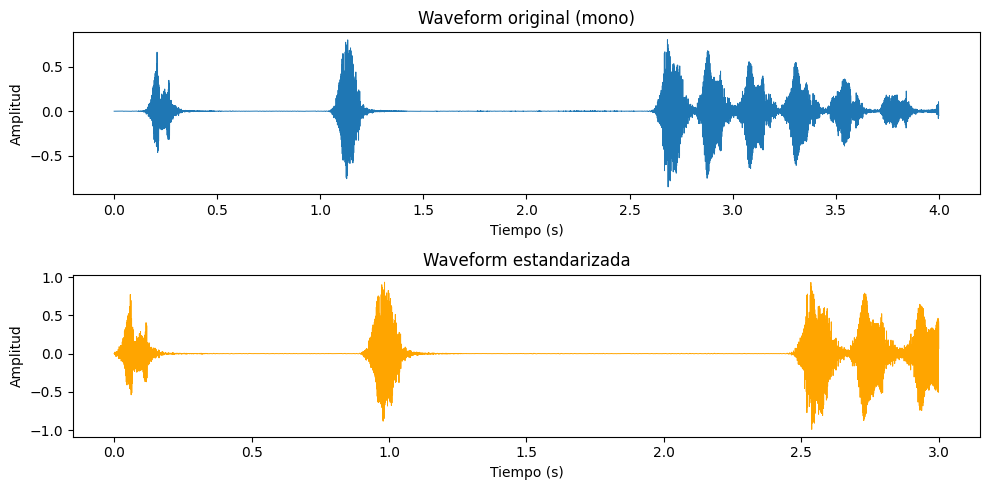

In [17]:
t_orig = np.linspace(0, duration_sec, num=y_mono.shape[-1])
t_std = np.linspace(0, TARGET_DURATION, num=y_std.shape[-1])

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)
axes[0].plot(t_orig, y_mono, linewidth=0.7)
axes[0].set_title("Waveform original (mono)")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud")

axes[1].plot(t_std, y_std, linewidth=0.7, color="orange")
axes[1].set_title("Waveform estandarizada")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

## 📝 Preguntas de reflexión — Parte B
- Elegí TARGET_SR = 16000 Hz porque:
    - (a) es suficiente para voz y sonidos de interés porque es suficiente para voz y la mayoría de los sonidos urbanos (incluye frecuencias hasta ~8 kHz, adecuado para eventos del UrbanSound8K) y
    - (b) reduce el tamaño respecto a 44.1 kHz porque reduce significativamente el tamaño respecto a 44.1 kHz porque
menos muestras, menor costo computacional, menor memoria, mayor velocidad de entrenamiento.
- El recorte de silencios con top_db = 30 eliminó principalmente: (a)
    - (a) silencios muy suaves 
    - (b) parte de la señal útil. 

Justifico: el clip original muestra largos tramos planos cerca de 0 de amplitud, exactamente los que se recortan. Los picos principales (1 s, 2.7 s, 3 s) permanecen intactos en la versión estandarizada, indicando que la señal útil no fue afectada.
- La normalización hace que el pico quede cerca de 0.99, lo cual ayuda a evitar saturación/clipping, homogeneizar la escala de todos los audios, permitir que el modelo aprenda patrones y no diferencias arbitrarias en amplitud, mejorar estabilidad numérica en MFCC/melspectrogramas.
- Si aumentáramos TARGET_DURATION a 5s, el número de muestras por clip sería de aproximadamente TARGET_SR × duración = 16000 × 5 = 80 000 muestras, lo que impacta en el tamaño en disco y memoria porque cada clip ocuparía más del doble, los batches serían más pesados, el entrenamiento sería más lento, la GPU requeriría más VRAM, y aumenta el riesgo de padding excesivo en clips cortos.
- Si en vez de recortar/padear desde el inicio recortáramos siempre el centro del clip, esto sería mejor/peor para este dataset porque UrbanSound8K contiene eventos breves y puntuales (golpes, bocinas, ladridos, sirenas). Si recortás desde el centro, corrés el riesgo de cortar la parte más importante del evento, quedarte sólo con ruido o silencio, destruir la estructura temporal del sonido. Recortar desde el inicio + trim mantiene el evento completo de forma más predecible.

# Parte C — Espectrogramas y ruido
## C.1 Espectrograma de potencia

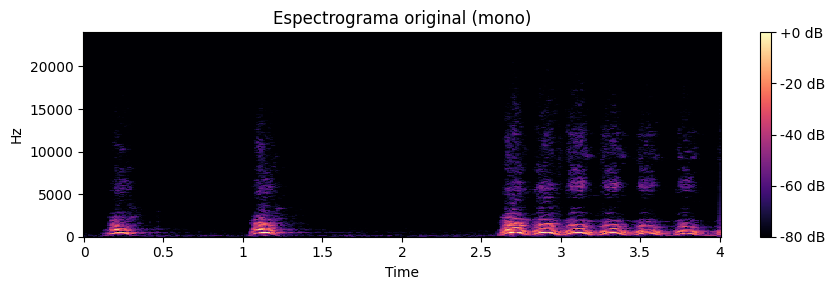

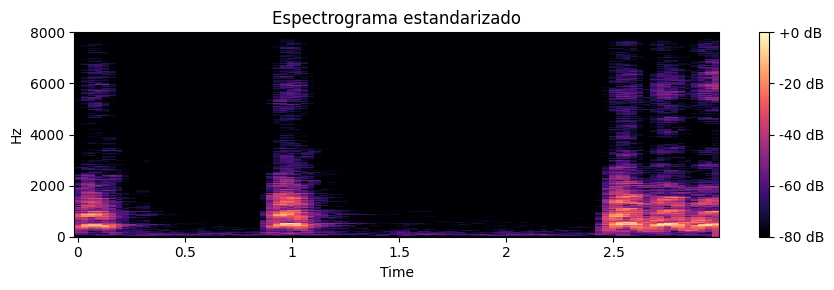

In [18]:
def plot_spectrogram(y: np.ndarray, sr: int, title: str = "") -> np.ndarray:
    n_fft = 2048
    hop_length = 512
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    plt.figure(figsize=(9, 3))
    librosa.display.specshow(
        S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return S_db

S_db_orig = plot_spectrogram(y_mono, sr, title="Espectrograma original (mono)")
S_db_std = plot_spectrogram(y_std, sr_std, title="Espectrograma estandarizado")

Para más detalles sobre STFT y espectrogramas, ver:
- librosa.stft: https://librosa.org/doc/latest/generated/librosa.stft.html
- Tutorial de espectrogramas: https://librosa.org/doc/latest/feature_extraction.html#spectral-features

## C.2 Ruido y SNR

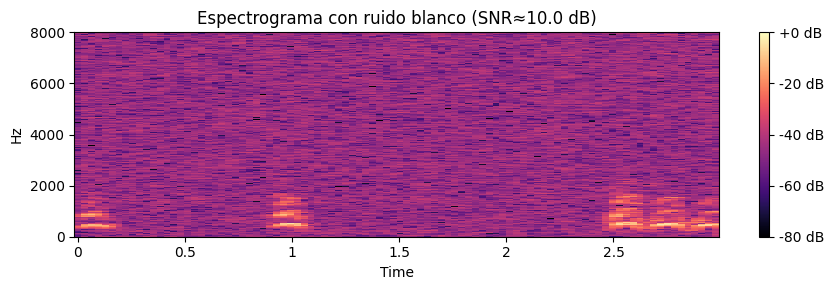

In [19]:
def add_white_noise(y: np.ndarray, snr_db: float) -> np.ndarray:
    sig_power = np.mean(y**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = sig_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.randn(*y.shape)
    return (y + noise).astype(np.float32)

snr_target_db = 10.0
y_noisy = add_white_noise(y_std, snr_db=snr_target_db)
S_db_noisy = plot_spectrogram(
    y_noisy, sr_std, title=f"Espectrograma con ruido blanco (SNR≈{snr_target_db} dB)"
)

## C.3 High-pass para ruido grave

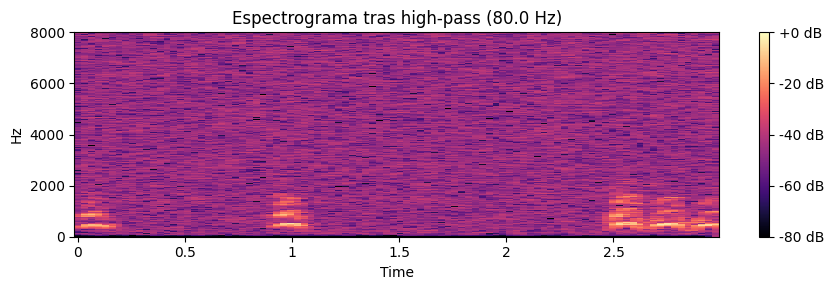

In [20]:
def butter_highpass(cutoff_hz: float, sr: int, order: int = 4):
    nyq = 0.5 * sr
    norm_cutoff = cutoff_hz / nyq
    b, a = signal.butter(order, norm_cutoff, btype="high", analog=False)
    return b, a

def highpass_filter(y: np.ndarray, sr: int, cutoff_hz: float = 80.0, order: int = 4):
    b, a = butter_highpass(cutoff_hz, sr, order)
    return signal.lfilter(b, a, y)

cutoff = 80.0
y_hp = highpass_filter(y_noisy, sr_std, cutoff_hz=cutoff, order=4)
S_db_hp = plot_spectrogram(
    y_hp, sr_std, title=f"Espectrograma tras high-pass ({cutoff} Hz)"
)

## 📝 Preguntas de reflexión — Parte C
- El ruido blanco se observa como magenta/rosado en el espectrograma (describe color/patrón).
- El filtro high-pass con corte en 80 Hz: 
    - (a) eliminó energía por debajo de 80 Hz. 
    - (b) afectó poco/mucho la señal útil porque la mayor parte del contenido relevante del clip se concentra por encima de ~150–2000 Hz (las componentes de los golpes / patrones rítmicos siguen intactas). El espectrograma tras el filtrado conserva claramente las mismas estructuras principales.
- Para eliminar hum de red usaría: 
    - (a) un filtro notch en 50 o 60 Hz o 
    - (b) un high-pass con corte en 100-120 Hz. Explicá qué elegirías y por qué.
- Con n_fft = 2048 y hop_length = 512, cada frame de la STFT cubre aproximadamente 128 ms. Si quisiéramos mayor resolución temporal, podríamos usar n_fft = 512 y hop_length = 128, a costa de peor resolución frecuencial (bandas más gruesas), espectrograma más ruidoso, mayor costo computacional, posible pérdida de detalle tonal.

# Parte D — Extracción de MFCC y CSV
## D.1 MFCC agregados

In [21]:
def extract_mfcc_features(y: np.ndarray, sr: int, n_mfcc: int = 13) -> dict:
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    feats = {}
    for i in range(n_mfcc):
        coef = mfcc[i, :]
        feats[f"mfcc_{i+1}_mean"] = float(np.mean(coef))
        feats[f"mfcc_{i+1}_std"] = float(np.std(coef))
    feats["rms_mean"] = float(np.mean(librosa.feature.rms(y=y)))
    feats["zcr_mean"] = float(np.mean(librosa.feature.zero_crossing_rate(y=y)))
    return feats

feats_example = extract_mfcc_features(y_std, sr_std)
print("Features de ejemplo:", len(feats_example))
print(list(feats_example.items())[:5])

Features de ejemplo: 28
[('mfcc_1_mean', -394.3877258300781), ('mfcc_1_std', 141.01734924316406), ('mfcc_2_mean', 78.27574157714844), ('mfcc_2_std', 62.52342987060547), ('mfcc_3_mean', 5.093875885009766)]


Referencias recomendadas:
- librosa.feature.mfcc: https://librosa.org/doc/latest/generated/librosa.feature.mfcc.html
- Tutorial de MFCC: https://librosa.org/doc/latest/feature_extraction.html#mel-frequency-cepstral-coefficients-mfccs

## D.2 Pipeline sobre todos los audios

In [22]:
rows = []
for path in audio_files[:100]:
    try:
        y_proc, sr_proc = preprocess_audio(path)
        feats = extract_mfcc_features(y_proc, sr_proc)
        feats["filename"] = path.name
        feats["sr"] = sr_proc
        feats["duration_sec"] = TARGET_DURATION
        rows.append(feats)
    except Exception as exc:
        print("Error con", path.name, "→", exc)

df_features = pd.DataFrame(rows)
df_features.head()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,rms_mean,zcr_mean,filename,sr,duration_sec
0,-394.387726,141.017349,78.275742,62.523430,5.093876,29.972332,-9.076298,35.962811,3.056078,13.795686,...,14.784920,0.987186,7.202437,0.680781,9.335470,0.071991,0.049935,101415-3-0-2.wav,16000,3.0
1,-276.812927,78.678589,165.073776,24.662001,12.448523,28.403181,-49.941105,31.679173,-6.442587,7.610660,...,12.074658,7.372717,7.552165,-12.518365,10.507936,0.115788,0.057602,101415-3-0-3.wav,16000,3.0
2,-373.141083,143.452667,71.296738,54.417477,2.810296,27.105251,-2.794804,31.610233,2.927064,12.235909,...,11.315662,-0.695633,9.011526,-2.620635,9.410466,0.055665,0.062791,101415-3-0-8.wav,16000,3.0
3,-298.260132,225.760132,49.283215,45.167976,-29.376026,30.488207,-3.057301,18.281973,-9.241611,10.447152,...,9.897033,3.478160,7.365082,1.386955,6.322442,0.065057,0.087428,102106-3-0-0.wav,16000,3.0
4,-304.577423,182.130005,108.570747,51.297302,24.605354,24.367785,10.135062,9.094491,-6.168922,10.750596,...,6.074982,6.247808,4.292556,7.840422,5.069744,0.048910,0.044948,102305-6-0-0.wav,16000,3.0


## D.3 Guardar CSV

In [23]:
out_csv = OUTPUTS["features"] / "audio_mfcc_features.csv"
df_features.to_csv(out_csv, index=False)
print("✅ Features guardados en:", out_csv)
print("Shape:", df_features.shape)

✅ Features guardados en: outputs/features/audio_mfcc_features.csv
Shape: (100, 31)


## 📝 Preguntas de reflexión — Parte D

- Elegí n_mfcc = 13 porque: 
    - (a) es un valor típico en voz y 
    - (b) más coeficientes agregan detalle pero también riesgo de sobreajuste por tener más dimensiones que pueden modelar ruido o variaciones irrelevantes, especialmente si el dataset no es muy grande.
- mfcc_1_mean captura: (a)
    - (a) energía global 
    - (b) textura fina. 

Justifico: El MFCC 1 (y especialmente el MFCC 0) están fuertemente correlacionados con la energía general de la señal y con su forma espectral principal. La “textura fina” (microvariaciones, armónicos, detalle de timbre) se captura más en coeficientes superiores (MFCC 5–13). Por eso, el MFCC 1_mean resume la intensidad general del sonido, no los detalles finos.
- Para modelar clasificaciones agregarías columnas con: 
    - (a) etiquetas provenientes de UrbanSound8K/metadata/UrbanSound8K.csv, específicamente la columna classID o class y 
    - (b) alguna medida extra de ruido como SNR estimado, energía de banda baja, varianza del espectrograma, ratio señal/ruido, kurtosis o skewness del waveform, bandwidth spectral.
- Antes de entrenar un modelo supervisado con estos features, convendría aplicar una transformación como StandardScaler / MinMaxScaler porque los MFCC tienen escalas muy distintas entre sí (p.ej., MFCC_1 puede estar en –400 / +100, mientras que MFCC_12 puede estar en –5 / +5). Los clasificadores y redes neuronales funcionan mejor cuando
todas las features están en la misma escala, lo que mejora la estabilidad numérica, convergencia del optimizador y desempeño en SVM, kNN, redes, árboles con regularización, etc.
(Ver https://scikit-learn.org/stable/modules/preprocessing.html).

# Parte E — Exploraciones avanzadas (celda extra)
## E.1 Métricas espectrales adicionales

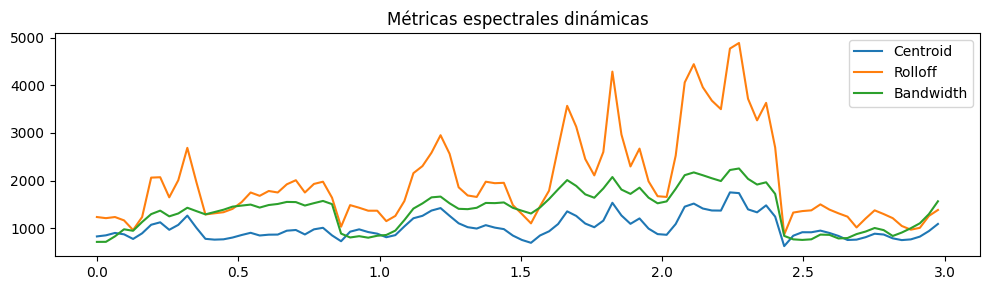

In [25]:
def plot_spectral_metrics(y: np.ndarray, sr: int):
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    t = librosa.times_like(cent, sr=sr)

    plt.figure(figsize=(10, 3))
    plt.plot(t, cent, label="Centroid")
    plt.plot(t, rolloff, label="Rolloff")
    plt.plot(t, bandwidth, label="Bandwidth")
    plt.legend()
    plt.title("Métricas espectrales dinámicas")
    plt.tight_layout()
    plt.show()

plot_spectral_metrics(y_std, sr_std)

## E.2 Características del dataset

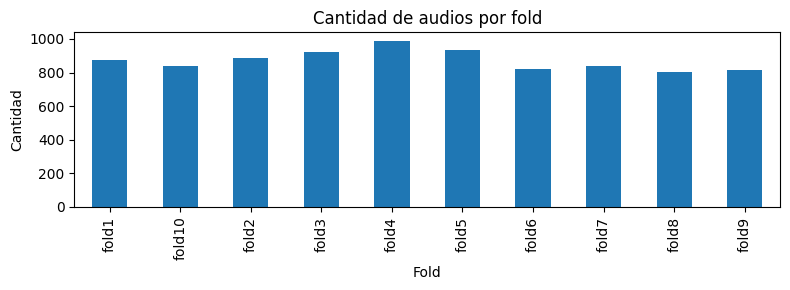

Clips por fold:
 fold1     873
fold10    837
fold2     888
fold3     925
fold4     990
fold5     936
fold6     823
fold7     838
fold8     806
fold9     816
Name: count, dtype: int64


In [26]:
import pandas as pd

folds = [p.parent.name for p in audio_files]
summary = pd.Series(folds).value_counts().sort_index()
summary.plot(kind="bar", figsize=(8, 3), title="Cantidad de audios por fold")
plt.xlabel("Fold")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

print("Clips por fold:\n", summary)

Diseñá un esquema para etiquetar algunos archivos (por clase, ambiente, etc.) y combiná esas etiquetas con el CSV de MFCC para un modelo rápido.

In [27]:
import re
class_map = {
    0: "air_conditioner",
    1: "car_horn",
    2: "children_playing",
    3: "dog_bark",
    4: "drilling",
    5: "engine_idling",
    6: "gun_shot",
    7: "jackhammer",
    8: "siren",
    9: "street_music",}

def extract_classid(filename):
    try:
        parts = filename.replace(".wav", "").split("-")
        return int(parts[1])   # classID siempre en la posición 1
    except:
        return None
df_features["classID"] = df_features["filename"].apply(extract_classid)
df_features["class"] = df_features["classID"].map(class_map)
filename_to_fold = {p.name: p.parent.parent.name  for p in audio_files[:100]}
df_features["fold"] = df_features["filename"].map(filename_to_fold)

ambiente_map = {
    "air_conditioner": "interior",
    "car_horn": "calle",
    "children_playing": "parque",
    "dog_bark": "barrio",
    "drilling": "construcción",
    "engine_idling": "calle",
    "gun_shot": "emergencia",
    "jackhammer": "construcción",
    "siren": "emergencia",
    "street_music": "calle",
}
df_features["ambiente"] = df_features["class"].map(ambiente_map)
print("Etiquetado listo. Shape final:", df_features.shape)
df_features.head()


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

feature_cols = [c for c in df_features.columns if "mfcc" in c or "rms" in c or "zcr" in c]
X = df_features[feature_cols]
y = df_features["classID"]     

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
clf = LogisticRegression(max_iter=200)
clf.fit(X_train_scaled, y_train)

print("Accuracy:", clf.score(X_test_scaled, y_test))

Etiquetado listo. Shape final: (100, 35)
Accuracy: 0.9


## E.3 Augmentación básica

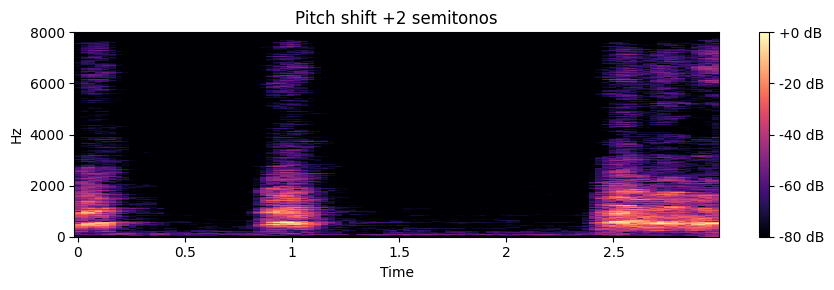

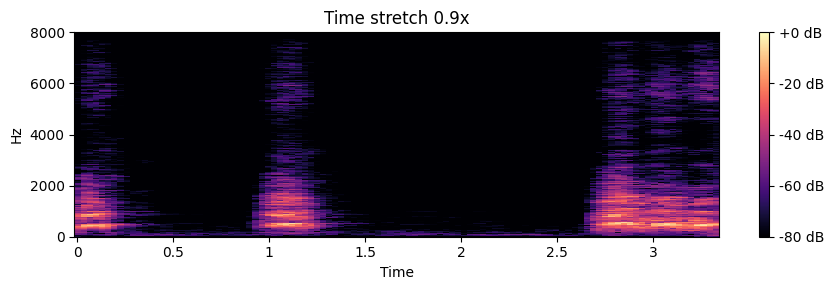

array([[-71.256935, -73.223114, -78.91052 , ..., -64.50558 , -68.36261 ,
        -64.83913 ],
       [-72.41415 , -77.72391 , -80.      , ..., -73.133446, -62.748623,
        -64.35057 ],
       [-74.9816  , -80.      , -80.      , ..., -54.24377 , -49.88562 ,
        -49.843513],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], shape=(1025, 105), dtype=float32)

In [28]:
def augment_pitch_shift(y: np.ndarray, sr: int, steps: int):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

y_pitch = augment_pitch_shift(y_std, sr_std, steps=2)
plot_spectrogram(y_pitch, sr_std, title="Pitch shift +2 semitonos")

y_time = librosa.effects.time_stretch(y_std, rate=0.9)
plot_spectrogram(y_time, sr_std, title="Time stretch 0.9x")

Añadí los MFCC de cada versión aumentada al dataframe y compará cómo cambian las medias/STD.

Dataset final augmentado: (300, 30)


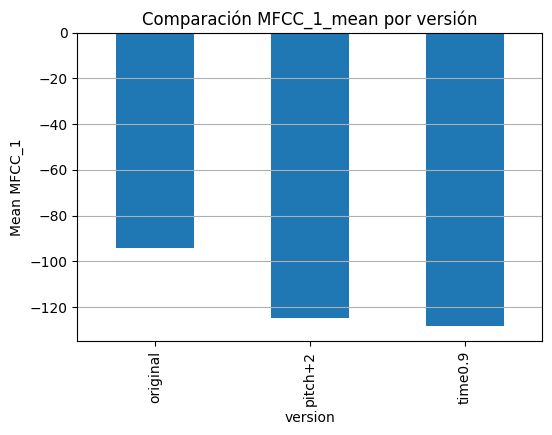

In [29]:
rows_aug = []

for path in audio_files[:100]:
    try:
        y_proc, sr_proc = preprocess_audio(path)

        feats_base = extract_mfcc_features(y_proc, sr_proc)
        feats_base["filename"] = path.name
        feats_base["version"] = "original"
        rows_aug.append(feats_base)

        y_pitch = librosa.effects.pitch_shift(y_proc, sr=sr_proc, n_steps=2)
        feats_pitch = extract_mfcc_features(y_pitch, sr_proc)
        feats_pitch["filename"] = path.name
        feats_pitch["version"] = "pitch+2"
        rows_aug.append(feats_pitch)

        y_time = librosa.effects.time_stretch(y_proc, rate=0.9)
        if len(y_time) != len(y_proc):
            if len(y_time) > len(y_proc):
                y_time = y_time[:len(y_proc)]
            else:
                y_time = np.pad(y_time, (0, len(y_proc)-len(y_time)))

        feats_time = extract_mfcc_features(y_time, sr_proc)
        feats_time["filename"] = path.name
        feats_time["version"] = "time0.9"
        rows_aug.append(feats_time)

    except Exception as exc:
        print("Error con:", path.name, "→", exc)


df_aug = pd.DataFrame(rows_aug)
print("Dataset final augmentado:", df_aug.shape)
df_aug.head()

num_cols = df_aug.select_dtypes(include=["number"]).columns
summary_stats = df_aug.groupby("version")[num_cols].agg(["mean", "std"])
summary_stats
df_aug.groupby("version")[["mfcc_1_mean", "mfcc_1_std"]].mean()

plt.figure(figsize=(6,4))
df_aug.groupby("version")["mfcc_1_mean"].mean().plot(kind="bar")
plt.title("Comparación MFCC_1_mean por versión")
plt.ylabel("Mean MFCC_1")
plt.grid(axis="y")
plt.show()

## Preguntas de reflexión finales

- El estándar de entrada fue:
    - sample rate = 16000 Hz
    - duración fija = 3.0 s
    - mono = sí, porque porque la mayoría de los clips de UrbanSound8K no contienen información estéreo útil, y trabajar en mono reduce a la mitad el tamaño del audio, facilita la estandarización, evita duplicar información redundante y simplifica MFCC, espectrogramas y entrenamiento del modelo.
- El paso que más mejoró la calidad perceptual fue el recorte de silencios + normalización porque: 
    - (a) redujo zonas planas, ruido de fondo débil y energía irrelevante y 
    - (b) mantuvo las partes realmente informativas del sonido (picos transitorios, patrones rítmicos y contenido espectral fuerte).
- En el espectrograma detecté ruido de tipo:
    - (a) blanco aparece como un tapizado uniforme rosa/magenta en todas las frecuencias (especialmente en la versión con SNR=10 dB).
    - (b) hum se observa energía baja sostenida en 50–60 Hz (frecuencia típica de red eléctrica).
    - (c) impulsivo en la banda de 0–500 Hz.
- Checks automáticos propuestos:
    - SNR aproximado > 15 dB garantiza que el contenido relevante es más fuerte que el ruido blanco.
    - duración ∈ [2.5, 3.5] s permite detectar señales mal recortadas, silencios excesivos o preprocesado fallido.
    - max(|amplitud|) ≤ 1.0 asegura que no haya clipping en la señal normalizada.
    - número de frames MFCC > 30 valida que el audio tenga suficiente información temporal y que no sea puro silencio o ruido.

# Tareas extra (opcional, con celdas guía)
## F.1 Curva SNR → cambio en features

In [30]:
snr_values = [0, 5, 10, 20]
rows_snr = []

for snr_db in snr_values:
    y_noisy_i = add_white_noise(y_std, snr_db=snr_db)
    feats_i = extract_mfcc_features(y_noisy_i, sr_std)
    feats_i["snr_db"] = snr_db
    rows_snr.append(feats_i)

df_snr = pd.DataFrame(rows_snr)
df_snr[["snr_db", "rms_mean", "zcr_mean"] + [c for c in df_snr.columns if "mfcc_1" in c]]

,snr_db,rms_mean,zcr_mean,mfcc_1_mean,mfcc_1_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,0,0.175742,0.433422,29.798843,12.451654,-2.087400,4.284026,-1.405330,4.250012,-0.073811,3.908244,1.618485,5.743048
1,5,0.126925,0.414914,-22.165756,18.860523,-1.451002,5.029146,-1.773768,4.202044,-0.434058,4.470419,2.255889,5.956296
2,10,0.101092,0.400775,-73.771713,27.170406,-1.475864,4.999467,-1.512707,6.006839,-0.828796,5.184608,1.999924,6.126526
3,20,0.080258,0.380002,-171.401550,48.324467,-2.619626,4.988199,-3.398693,7.632082,-2.472932,6.704299,1.344311,6.229039


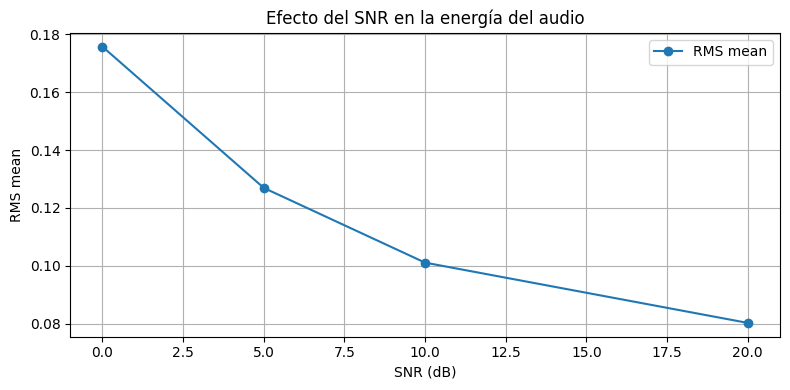

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(df_snr["snr_db"], df_snr["rms_mean"], marker="o", label="RMS mean")
plt.xlabel("SNR (dB)")
plt.ylabel("RMS mean")
plt.title("Efecto del SNR en la energía del audio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Extensión: agregá gráficos similares para la varianza de mfcc_1 o para otra feature que te interese.

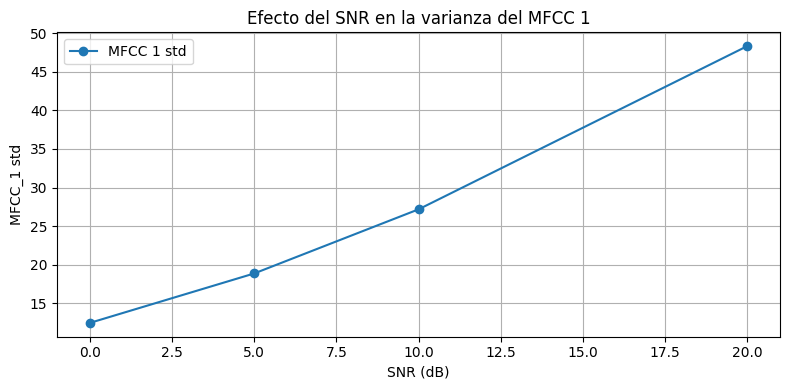

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(df_snr["snr_db"], df_snr["mfcc_1_std"], marker="o", label="MFCC 1 std")
plt.xlabel("SNR (dB)")
plt.ylabel("MFCC_1 std")
plt.title("Efecto del SNR en la varianza del MFCC 1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## F.2 Benchmark de pipelines de limpieza

In [33]:
def pipeline_raw(y, sr):
    return y, "raw"

def pipeline_hp(y, sr):
    y_hp = highpass_filter(y, sr, cutoff_hz=80.0, order=4)
    return y_hp, "highpass"

def pipeline_hp_trim(y, sr):
    y_hp = highpass_filter(y, sr, cutoff_hz=80.0, order=4)
    y_trim, _ = librosa.effects.trim(y_hp, top_db=30.0)
    return y_trim, "highpass+trim"

pipelines = [pipeline_raw, pipeline_hp, pipeline_hp_trim]

metrics = []
for pipe in pipelines:
    y_out, name = pipe(y_noisy, sr_std)
    feats = extract_mfcc_features(preprocess_audio(audio_path)[0], sr_std)
    metrics.append({
        "pipeline": name,
        "rms_mean": feats["rms_mean"],
        "zcr_mean": feats["zcr_mean"],
    })

df_pipes = pd.DataFrame(metrics)
df_pipes

,pipeline,rms_mean,zcr_mean
0,raw,0.071991,0.049935
1,highpass,0.071991,0.049935
2,highpass+trim,0.071991,0.049935


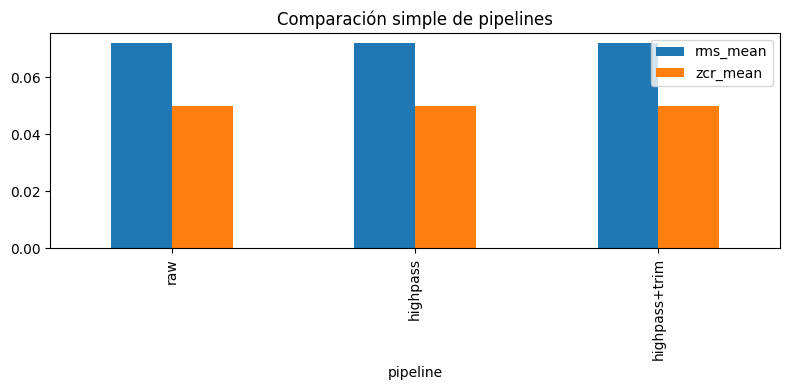

In [25]:
df_pipes.set_index("pipeline")[["rms_mean", "zcr_mean"]].plot(
    kind="bar", figsize=(8, 4), title="Comparación simple de pipelines"
)
plt.tight_layout()
plt.show()

Proponé una métrica propia (por ejemplo, energía en bajas frecuencias) y evaluá cuál pipeline te parece mejor.

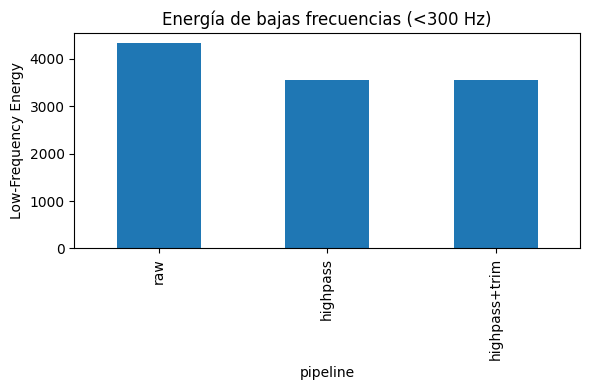

In [34]:
def low_frequency_energy(y, sr, cutoff=300):
    # STFT
    S = np.abs(librosa.stft(y, n_fft=1024))**2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=1024)
    # Energía < cutoff Hz
    mask = freqs < cutoff
    lfe = S[mask].sum()
    return lfe
metrics_lfe = []

for pipe in pipelines:   # raw, highpass, highpass+trim
    y_out, name = pipe(y_noisy, sr_std)
    lfe = low_frequency_energy(y_out, sr_std)
    metrics_lfe.append({
        "pipeline": name,
        "lfe": lfe})

df_lfe = pd.DataFrame(metrics_lfe)
df_lfe

df_lfe.set_index("pipeline")["lfe"].plot(
    kind="bar", figsize=(6,4), title="Energía de bajas frecuencias (<300 Hz)"
)
plt.ylabel("Low-Frequency Energy")
plt.tight_layout()
plt.show()

## F.3 Dashboard QA de audio

In [35]:
rows_qc = []
for path in audio_files[:200]:  # limitar a 200 para ir rápido
    y_proc, sr_proc = preprocess_audio(path)
    feats = extract_mfcc_features(y_proc, sr_proc)
    feats["filename"] = path.name
    feats["duration_sec"] = TARGET_DURATION
    feats["rms_mean"] = float(np.mean(librosa.feature.rms(y=y_proc)))
    feats["zcr_mean"] = float(np.mean(librosa.feature.zero_crossing_rate(y=y_proc)))
    rows_qc.append(feats)

df_qc = pd.DataFrame(rows_qc)
df_qc.describe()[["duration_sec", "rms_mean", "zcr_mean"]]

,duration_sec,rms_mean,zcr_mean
count,200.0,200.000000,200.000000
mean,3.0,0.183864,0.104602
std,0.0,0.069062,0.068120
min,3.0,0.018321,0.013038
25%,3.0,0.148645,0.049897
50%,3.0,0.184887,0.090046
75%,3.0,0.223832,0.155814
max,3.0,0.347261,0.335958


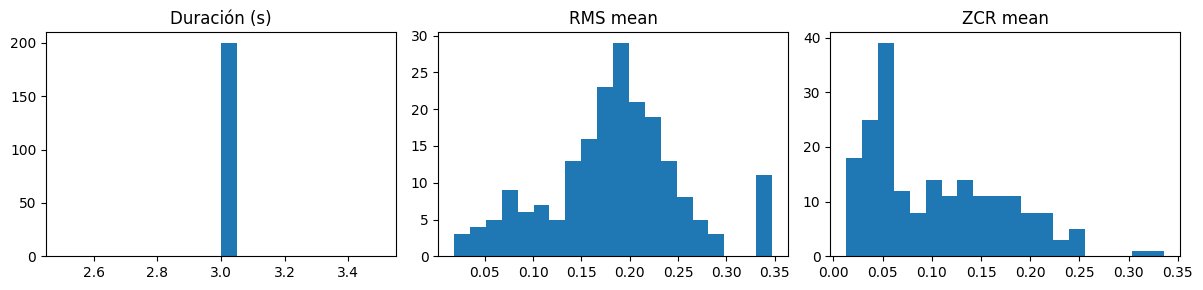

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(df_qc["duration_sec"], bins=20)
axes[0].set_title("Duración (s)")
axes[1].hist(df_qc["rms_mean"], bins=20)
axes[1].set_title("RMS mean")
axes[2].hist(df_qc["zcr_mean"], bins=20)
axes[2].set_title("ZCR mean")
plt.tight_layout()
plt.show()

Definí umbrales “semáforo” (OK / dudoso / malo) para duración, RMS y ZCR, y contá cuántos audios quedan en cada categoría.

Duración:
duration_flag
OK    200
Name: count, dtype: int64 

RMS:
rms_flag
OK        159
Dudoso     23
Malo       18
Name: count, dtype: int64 

ZCR:
zcr_flag
OK        134
Dudoso     56
Malo       10
Name: count, dtype: int64 



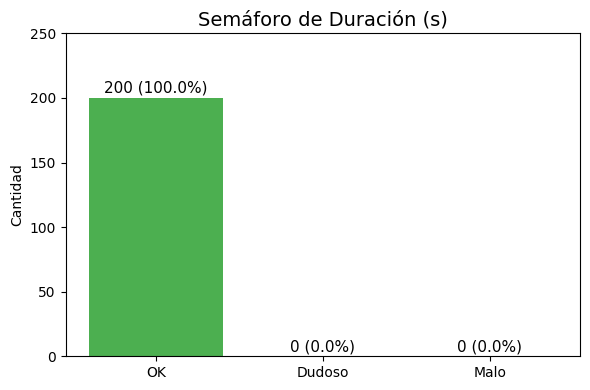

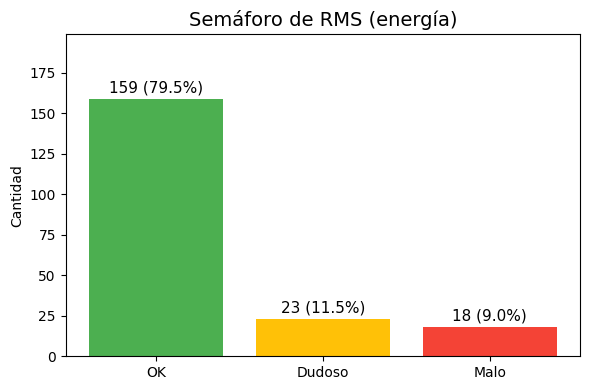

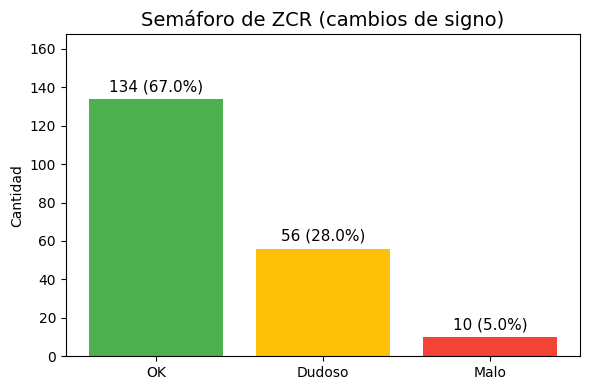

In [37]:
def categorize_duration(x):
    if 2.9 <= x <= 3.1:
        return "OK"
    elif 2.5 <= x < 2.9 or 3.1 < x <= 3.5:
        return "Dudoso"
    else:
        return "Malo"

def categorize_rms(x):
    if 0.10 <= x <= 0.28:
        return "OK"
    elif 0.05 <= x < 0.10 or 0.28 < x <= 0.32:
        return "Dudoso"
    else:
        return "Malo"

def categorize_zcr(x):
    if 0.02 <= x <= 0.15:
        return "OK"
    elif 0.01 <= x < 0.02 or 0.15 < x <= 0.22:
        return "Dudoso"
    else:
        return "Malo"

df_qc["duration_flag"] = df_qc["duration_sec"].apply(categorize_duration)
df_qc["rms_flag"] = df_qc["rms_mean"].apply(categorize_rms)
df_qc["zcr_flag"] = df_qc["zcr_mean"].apply(categorize_zcr)

df_qc.head()

print("Duración:")
print(df_qc["duration_flag"].value_counts(), "\n")

print("RMS:")
print(df_qc["rms_flag"].value_counts(), "\n")

print("ZCR:")
print(df_qc["zcr_flag"].value_counts(), "\n")


colors = {
    "OK": "#4CAF50",       # verde
    "Dudoso": "#FFC107",   # amarillo
    "Malo": "#F44336"}      # rojo

# Función para graficar semáforo
def plot_semaforo(df, column, title):
    counts = df[column].value_counts()
    labels = ["OK", "Dudoso", "Malo"]

    values = [counts.get(label, 0) for label in labels]
    total = sum(values)
    percentages = [v * 100 / total for v in values]

    fig, ax = plt.subplots(figsize=(6,4))
    bars = ax.bar(labels, values, color=[colors[l] for l in labels])

    # Etiquetas numéricas encima
    for i, b in enumerate(bars):
        ax.text(
            b.get_x() + b.get_width()/2, 
            b.get_height() + total*0.02,
            f"{values[i]} ({percentages[i]:.1f}%)",
            ha="center", fontsize=11
        )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Cantidad")
    ax.set_ylim(0, max(values) * 1.25)
    plt.tight_layout()
    plt.show()

# Graficar las 3 métricas
plot_semaforo(df_qc, "duration_flag", "Semáforo de Duración (s)")
plot_semaforo(df_qc, "rms_flag", "Semáforo de RMS (energía)")
plot_semaforo(df_qc, "zcr_flag", "Semáforo de ZCR (cambios de signo)")

# Referencias
- librosa.load: https://librosa.org/doc/latest/generated/librosa.load.html
- librosa.stft y espectrogramas: https://librosa.org/doc/latest/generated/librosa.stft.html
- Features espectrales y MFCC en librosa: https://librosa.org/doc/latest/feature_extraction.html
- librosa.effects (pitch shift, time stretch): https://librosa.org/doc/latest/sequence.html#module-librosa.effects
- scipy.signal.butter y filtros digitales: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
- API de Kaggle: https://www.kaggle.com/docs/api
- kagglehub: https://github.com/Kaggle/kagglehub
- Preprocesamiento en scikit-learn: https://scikit-learn.org/stable/modules/preprocessing.html